## Template d’Analyse Exploratoire de Données (AED)

Ce notebook sert de point de départ rapide pour les AED.

Sections incluses:
- Imports et configuration
- Chargement des données (Excel, CSV/URL)
- Description du dataset (types, échelles, % manquants)
- Nettoyage (doublons, conversions, renommage de colonnes)
- Analyse de la cible et de son équilibre
- Blocs de statistiques (globales et groupées par cible)
- Visualisations (boxplots vs cible, heatmap avec seuil ajustable)

Paramétrer la cellule « Paramètres » puis exécuter séquentiellement.


In [18]:
# Paramètres
projectName = "Projet AED"
randomSeed = 42

# Options de chargement par défaut
# dataSource peut être "excel" ou "csv_url"
dataSource = "excel"
excelPath = "./bcw_data.xlsx"  # ajustez selon votre projet
sheetName = 0

csvUrl = ""  # ex: "https://example.com/data.csv"

# Cible et colonnes utiles
# targetColumn sera utilisée pour l'équilibre des classes et les groupby
targetColumn = "diagnosis"  # ex: "target"

# Colonnes numériques/catégorielles (laisser None pour détection auto)
numericColumns = None
categoricalColumns = None

# Paramètres d'affichage
maxRowsToShow = 10
floatPrecision = 10

# Paramètres de visualisation
heatmapCorrThreshold = 0.95  # seuil minimal de corrélation à afficher
figSize = (10, 6)


In [19]:
# Création du requirements.txt (à exécuter avant les imports)
from pathlib import Path

# Liste simple des packages requis pour ce notebook (modifiez selon besoin)
packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scipy",
    "openpyxl",      # lecture Excel
    "scikit-learn",  # ML éventuel
    "SQLAlchemy",    # chargement SQL optionnel
]

# Tri + déduplication (sans versions)
requirements = sorted(set(packages), key=lambda x: x.lower())

outPath = Path("requirements.txt")
outPath.write_text("\n".join(requirements), encoding="utf-8")
print(f"requirements.txt écrit: {outPath.resolve()}")
print("Installez ensuite avec: pip install -r requirements.txt")
print("Contenu:\n" + "\n".join(requirements))


requirements.txt écrit: C:\Users\Emile de Saint-Seine\Documents\Projet la Plateforme\Perceptron\requirements.txt
Installez ensuite avec: pip install -r requirements.txt
Contenu:
matplotlib
numpy
openpyxl
pandas
scikit-learn
scipy
seaborn
SQLAlchemy


In [20]:
# Imports et configuration globale
import os
import sys
import math
import warnings
from typing import Optional, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Affichage
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.precision", floatPrecision)

np.random.seed(randomSeed)
warnings.filterwarnings("ignore")

print(f"Projet: {projectName} - seed={randomSeed}")
print(f"Version pandas: {pd.__version__}, numpy: {np.__version__}")


Projet: Projet AED - seed=42
Version pandas: 2.3.3, numpy: 2.3.3


In [21]:
# Chargement des données — fonctions utilitaires
from urllib.parse import urlparse

try:
    from sqlalchemy import create_engine
except Exception:
    create_engine = None


def loadFromExcel(path: str, sheet: int | str = 0) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return pd.read_excel(path, sheet_name=sheet)


def loadFromCsvUrl(url: str) -> pd.DataFrame:
    parsed = urlparse(url)
    if not parsed.scheme:
        # Peut être un chemin local CSV
        if not os.path.exists(url):
            raise FileNotFoundError(f"Ni URL ni fichier CSV local valide: {url}")
        return pd.read_csv(url)
    return pd.read_csv(url)


def loadFromSql(connString: str, query: str) -> pd.DataFrame:
    if create_engine is None:
        raise ImportError("SQLAlchemy n'est pas installé. Ajoutez-le si vous utilisez SQL.")
    if not connString:
        raise ValueError("sqlConnString est vide.")
    engine = create_engine(connString)
    with engine.connect() as conn:
        return pd.read_sql_query(query, conn)


def unifiedLoad(dataSource: str) -> pd.DataFrame:
    source = dataSource.lower().strip()
    if source == "excel":
        return loadFromExcel(excelPath, sheetName)
    if source == "csv_url":
        if not csvUrl:
            raise ValueError("csvUrl est vide.")
        return loadFromCsvUrl(csvUrl)


In [22]:
# Chargement effectif des données
try:
    df = unifiedLoad(dataSource)
    print(f"Données chargées: {df.shape[0]} lignes, {df.shape[1]} colonnes")
    display(df.head(maxRowsToShow))
except Exception as e:
    print("Erreur lors du chargement:", e)
    df = pd.DataFrame()


Données chargées: 569 lignes, 32 colonnes


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [23]:
# Description du dataset
assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"

def detectColumnTypes(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    if numericColumns is not None and categoricalColumns is not None:
        return list(numericColumns), list(categoricalColumns)
    inferredNumeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    inferredCategorical = [c for c in df.columns if c not in inferredNumeric]
    return inferredNumeric, inferredCategorical

numCols, catCols = detectColumnTypes(df)
print("Colonnes numériques:", numCols)
print("Colonnes catégorielles:", catCols)

# % de données manquantes (NaN uniquement)
"""missingPct = df.isna().mean().sort_values(ascending=False) * 100
print("% de données manquantes par colonne:")
display(missingPct.to_frame(name="missing_%").T if missingPct.empty else missingPct)"""

# % de données manquantes en traitant 0 comme manquant pour les colonnes numériques
if len(numCols) > 0:
    missingOrZero = df.isna().copy()
    try:
        missingOrZero[numCols] = missingOrZero[numCols] | (df[numCols] == 0)
    except Exception:
        numMask = df[numCols].apply(pd.to_numeric, errors="coerce") == 0
        missingOrZero[numCols] = missingOrZero[numCols] | numMask
    missingOrZeroPct = missingOrZero.mean().sort_values(ascending=False) * 100
    print("% de données manquantes OU égales à 0 (numériques: 0 considéré manquant):")
    display(missingOrZeroPct.to_frame(name="missing_or_zero_%").T if missingOrZeroPct.empty else missingOrZeroPct)

# Doublons (toutes colonnes)
duplicateCount = int(df.duplicated().sum())
duplicatePct = (duplicateCount / len(df) * 100) if len(df) > 0 else 0
print(f"Lignes dupliquées (toutes colonnes): {duplicateCount} ({duplicatePct:.2f}%)")
if duplicateCount > 0:
    print("Exemples de lignes dupliquées:")
    display(df[df.duplicated(keep=False)].head(maxRowsToShow))

# Aperçu dtypes
display(df.dtypes.to_frame(name="dtype"))


Colonnes numériques: ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Colonnes catégorielles: ['diagnosis']
% de données manquantes OU égales à 0 (numériques: 0 considéré manquant):


concave points_mean        2.2847100176
concavity_mean             2.2847100176
concavity_se               2.2847100176
concave points_se          2.2847100176
concave points_worst       2.2847100176
concavity_worst            2.2847100176
id                         0.0000000000
diagnosis                  0.0000000000
compactness_mean           0.0000000000
smoothness_mean            0.0000000000
symmetry_mean              0.0000000000
fractal_dimension_mean     0.0000000000
perimeter_mean             0.0000000000
area_mean                  0.0000000000
radius_mean                0.0000000000
texture_mean               0.0000000000
area_se                    0.0000000000
perimeter_se               0.0000000000
texture_se                 0.0000000000
radius_se                  0.0000000000
symmetry_se                0.0000000000
fractal_dimension_se       0.0000000000
compactness_se             0.0000000000
smoothness_se              0.0000000000
texture_worst              0.0000000000


Lignes dupliquées (toutes colonnes): 0 (0.00%)


,dtype
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [24]:
# Outils de nettoyage: doublons, conversions, renommages
from typing import Dict


def dropDuplicates(data: pd.DataFrame, subset: Optional[list[str]] = None, keep: str = "first") -> pd.DataFrame:
    before = len(data)
    out = data.drop_duplicates(subset=subset, keep=keep)
    print(f"Doublons supprimés: {before - len(out)}")
    return out


def convertColumns(data: pd.DataFrame, conversions: Dict[str, str | type]) -> pd.DataFrame:
    out = data.copy()
    for col, dtype in conversions.items():
        if col not in out.columns:
            print(f"Colonne absente, ignorée: {col}")
            continue
        try:
            if dtype == "category":
                out[col] = out[col].astype("category")
            elif dtype == "datetime":
                out[col] = pd.to_datetime(out[col], errors="coerce")
            else:
                out[col] = out[col].astype(dtype)
            print(f"Converti {col} -> {dtype}")
        except Exception as e:
            print(f"Échec conversion {col} -> {dtype}: {e}")
    return out


def renameColumns(data: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    missing = [c for c in mapping.keys() if c not in data.columns]
    if missing:
        print("Attention, colonnes à renommer introuvables:", missing)
    return data.rename(columns=mapping)

# Exemples d'utilisation (décommenter et adapter):
# df = dropDuplicates(df)
# df = convertColumns(df, {"date_col": "datetime", "code": "category", "age": "float64"})
# df = renameColumns(df, {"oldName": "newName"})


In [25]:
# Analyse de la cible et de son équilibre
from collections import Counter

if targetColumn is None or targetColumn not in df.columns:
    print("Définissez targetColumn pour activer l'analyse de la cible.")
else:
    targetSeries = df[targetColumn]
    print("Aperçu de la cible:")
    display(targetSeries.value_counts(dropna=False).to_frame(name="count"))
    vc = targetSeries.value_counts(normalize=True, dropna=False) * 100
    print("Répartition (%) de la cible:")
    display(vc.to_frame(name="percentage"))

    # Mesure simple d'équilibre: ratio minoritaire/majoritaire (hors NaN)
    vcNoNa = targetSeries.dropna().value_counts()
    if len(vcNoNa) >= 2:
        minority = vcNoNa.min()
        majority = vcNoNa.max()
        balanceRatio = minority / majority
        print(f"Balance ratio (minority/majority): {balanceRatio:.3f}")
    else:
        print("La cible n'a pas au moins 2 classes non nulles.")


Aperçu de la cible:


,count
diagnosis,
B,357
M,212


Répartition (%) de la cible:


,percentage
diagnosis,
B,62.7416520211
M,37.2583479789


Balance ratio (minority/majority): 0.594


In [26]:
# Statistiques descriptives

statsFunctions = [
    ("mean", np.mean),
    ("median", np.median),
    ("min", np.min),
    ("q1", lambda x: np.nanpercentile(x, 25)),
    ("q3", lambda x: np.nanpercentile(x, 75)),
    ("max", np.max),
    ("var", np.var),
    ("std", np.std),
    ("iqr", lambda x: np.nanpercentile(x, 75) - np.nanpercentile(x, 25)),
    ("range", lambda x: np.nanmax(x) - np.nanmin(x)),
]

if len(numCols) == 0:
    print("Aucune colonne numérique détectée.")
else:
    print("Statistiques globales:")
    globalStats = pd.concat({name: df[numCols].apply(func) for name, func in statsFunctions}, axis=1).T
    display(globalStats)

    if targetColumn is not None and targetColumn in df.columns:
        print("Statistiques groupées par cible:")
        groupedStats = pd.concat({name: df.groupby(targetColumn)[numCols].aggregate(func) for name, func in statsFunctions}, axis=0)
        display(groupedStats)
    else:
        print("Définissez targetColumn pour obtenir les stats groupées.")


Statistiques globales:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
mean,3.0371831432e+07,14.1272917399,19.2896485062,91.9690333919,654.8891036907,0.0963602812,0.1043409842,0.0887993158,0.0489191459,0.1811618629,0.0627976098,0.4051720562,1.2168534271,2.8660592267,40.3370790861,0.0070409789,0.0254781388,0.0318937163,0.0117961371,0.0205422988,0.0037949039,16.2691898067,25.6772231986,107.2612126538,880.5831282953,0.1323685940,0.2542650439,0.2721884833,0.1146062232,0.2900755712,0.0839458172
median,9.0602400000e+05,13.3700000000,18.8400000000,86.2400000000,551.1000000000,0.0958700000,0.0926300000,0.0615400000,0.0335000000,0.1792000000,0.0615400000,0.3242000000,1.1080000000,2.2870000000,24.5300000000,0.0063800000,0.0204500000,0.0258900000,0.0109300000,0.0187300000,0.0031870000,14.9700000000,25.4100000000,97.6600000000,686.5000000000,0.1313000000,0.2119000000,0.2267000000,0.0999300000,0.2822000000,0.0800400000
min,8.6700000000e+03,6.9810000000,9.7100000000,43.7900000000,143.5000000000,0.0526300000,0.0193800000,0.0000000000,0.0000000000,0.1060000000,0.0499600000,0.1115000000,0.3602000000,0.7570000000,6.8020000000,0.0017130000,0.0022520000,0.0000000000,0.0000000000,0.0078820000,0.0008948000,7.9300000000,12.0200000000,50.4100000000,185.2000000000,0.0711700000,0.0272900000,0.0000000000,0.0000000000,0.1565000000,0.0550400000
q1,8.6921800000e+05,11.7000000000,16.1700000000,75.1700000000,420.3000000000,0.0863700000,0.0649200000,0.0295600000,0.0203100000,0.1619000000,0.0577000000,0.2324000000,0.8339000000,1.6060000000,17.8500000000,0.0051690000,0.0130800000,0.0150900000,0.0076380000,0.0151600000,0.0022480000,13.0100000000,21.0800000000,84.1100000000,515.3000000000,0.1166000000,0.1472000000,0.1145000000,0.0649300000,0.2504000000,0.0714600000
q3,8.8131290000e+06,15.7800000000,21.8000000000,104.1000000000,782.7000000000,0.1053000000,0.1304000000,0.1307000000,0.0740000000,0.1957000000,0.0661200000,0.4789000000,1.4740000000,3.3570000000,45.1900000000,0.0081460000,0.0324500000,0.0420500000,0.0147100000,0.0234800000,0.0045580000,18.7900000000,29.7200000000,125.4000000000,1084.0000000000,0.1460000000,0.3391000000,0.3829000000,0.1614000000,0.3179000000,0.0920800000
max,9.1132050200e+08,28.1100000000,39.2800000000,188.5000000000,2501.0000000000,0.1634000000,0.3454000000,0.4268000000,0.2012000000,0.3040000000,0.0974400000,2.8730000000,4.8850000000,21.9800000000,542.2000000000,0.0311300000,0.1354000000,0.3960000000,0.0527900000,0.0789500000,0.0298400000,36.0400000000,49.5400000000,251.2000000000,4254.0000000000,0.2226000000,1.0580000000,1.2520000000,0.2910000000,0.6638000000,0.2075000000
var,1.5602677324e+16,12.3970942594,18.4663974160,589.4027985384,123625.9030798645,0.0001974521,0.0027842855,0.0063440787,0.0015030146,0.0007502220,0.0000497611,0.0767671984,0.3037811232,4.0807114865,2065.7946205087,0.0000089993,0.0003201393,0.0009095968,0.0000380055,0.0000682128,0.0000069894,23.3191692997,37.7100917621,1127.1464342061,323597.6708928500,0.0005204036,0.0247112650,0.0434475982,0.0043131471,0.0038208567,0.0003256361
std,1.2491067738e+08,3.5209507607,4.2972546371,24.2776192931,351.6047540632,0.0140517641,0.0527663291,0.0796497253,0.0387687325,0.0273901809,0.0070541559,0.2770689415,0.5511634269,2.0200770991,45.4510134156,0.0029998784,0.0178924359,0.0301595231,0.0061648607,0.0082591044,0.0026437448,4.8289925761,6.1408543186,33.5730015668,568.8564589533,0.0228123569,0.1571981711,0.2084408746,0.0656745545,0.0618130785,0.0180453893
iqr,7.9439110000e+06,4.0800000000,5.6300000000,28.9300000000,362.4000000000,0.0189300000,0.0654800000,0.1011400000,0.0536900000,0.0338000000,0.0084200

Statistiques groupées par cible:


id    radius_mean   texture_mean  perimeter_mean          area_mean  smoothness_mean  compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
       diagnosis                                                                                                                                                                             
mean   B          2.6543824625e+07  12.1465238095  17.9147619048   78.0754061625     462.7901960784     0.0924776471      0.0800846218    0.0460576210         0.0257174062   0.1741859944   
       M          3.6818050443e+07  17.4628301887  21.6049056604  115.3653773585     978.3764150943     0.1028984906      0.1451877830    0.1607747170         0.0879900000   0.1929089623   
median B          9.0891600000e+05  12.2000000000  17.3900000000   78.1800000000     458.4000000000     0.0907600000      0.0752900000    0.0370900000         0.0234400000   0.1714000000   
       M          8.9536650000e+05  17.3250000000  21.4600000000  114.2000000000     932.0000000000     0.1022000000      0.1323500000    0.1513500000         0.0862800000   0.1899000000   
min    B          8.9130000000e+03   6.9810000000   9.7100000000   43.7900000000     143.5000000000     0.0526300000      0.0193800000    0.0000000000         0.0000000000   0.1060000000   
       M          8.6700000000e+03  10.9500000000  10.3800000000   71.9000000000     361.6000000000     0.0737100000      0.0460500000    0.0239800000         0.0203100000   0.1308000000   
q1     B          8.7466200000e+05  11.0800000000  15.1500000000   70.8700000000     378.2000000000     0.0830600000      0.0556200000    0.0203100000         0.0150200000   0.1580000000   
       M          8.6134500000e+05  15.0750000000  19.3275000000   98.7450000000     705.3000000000     0.0940100000      0.1096000000    0.1095250000         0.0646200000   0.1740500000   
q3     B          8.8128160000e+06  13.3700000000  19.7600000000   86.1000000000     551.1000000000     0.1007000000      0.0975500000    0.0599900000         0.0325100000   0.1890000000   
       M          8.9112897500e+06  19.5900000000  23.7650000000  129.9250000000    1203.7500000000     0.1109250000      0.1724000000    0.2030500000         0.1031750000   0.2098500000   
max    B          9.1132050200e+08  17.8500000000  33.8100000000  114.6000000000     992.1000000000     0.1634000000      0.2239000000    0.4108000000         0.0853400000   0.2743000000   
       M          9.1129620200e+08  28.1100000000  39.2800000000  188.5000000000    2501.0000000000     0.1447000000      0.3454000000    0.4268000000         0.2012000000   0.3040000000   
var    B          1.3628148690e+16   3.1702217220  15.9610205190  139.4155822082   18033.0301002423     0.0001807970      0.0011390594    0.0018872205         0.0002530892   0.0006153753   
       M          1.9015458403e+16  10.2654308146  14.2843928821  477.6258704730  135378.3553652867     0.0001589676      0.0029146496    0.0056278996         0.0011815656   0.0007638641   
std    B          1.1673966203e+08   1.7805116461   3.9951245937   11.8074375801     134.2871181471     0.0134460773      0.0337499546    0.0434421510         0.0159087784   0.0248067582   
       M          1.3789654964e+08   3.2039711008   3.7794699208   21.8546532911     367.9379776067     0.0126082355      0.0539874951    0.0750193279         0.0343739089   0.0276380921   
iqr    B          7.9381540000e+06   2.2900000000   4.6100000000   15.2300000000     172.9000000000     0.0176400000      0.0419300000    0.0396800000         0.0174900000   0.0310000000   
       M          8.0499447500e+06   4.5150000000   4.4375000000   31.1800000000     498.4500000000     0.0169150000      0.0628000000    0.0935250000         0.0385550000   0.0358000000   
range  B          9.1131158900e+08  10.8690000000  24.1000000000   70.8100000000     848.6000000000     0.1107700000      0.2045200000    0.4108000000         0.0853400000   0.1683000000   
       M          9.1128753200e+08  17.160

In [27]:
# Imputation des zéros par la médiane conditionnelle à la cible
# Pour chaque colonne numérique, on remplace 0 par la médiane calculée au sein de chaque classe de `targetColumn`.

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"
if targetColumn is None or targetColumn not in df.columns:
    print("Avertissement: targetColumn non définie ou absente. Imputation globale (médiane globale) pour 0.")
    for col in numCols:
        if col in df.columns:
            medianVal = df[col].replace(0, np.nan).median()
            df.loc[df[col] == 0, col] = medianVal
else:
    for col in numCols:
        if col not in df.columns:
            continue
        # Calcule la médiane par classe (en ignorant les 0 en les remplaçant par NaN)
        mediansByClass = df.replace({col: {0: np.nan}}).groupby(targetColumn)[col].median()
        # Applique la médiane de la classe correspondante là où la valeur est 0
        maskZero = df[col] == 0
        if maskZero.any():
            df.loc[maskZero, col] = df.loc[maskZero, targetColumn].map(mediansByClass)

print("Imputation terminée: zéros remplacés par la médiane (par classe si cible définie).")


Imputation terminée: zéros remplacés par la médiane (par classe si cible définie).


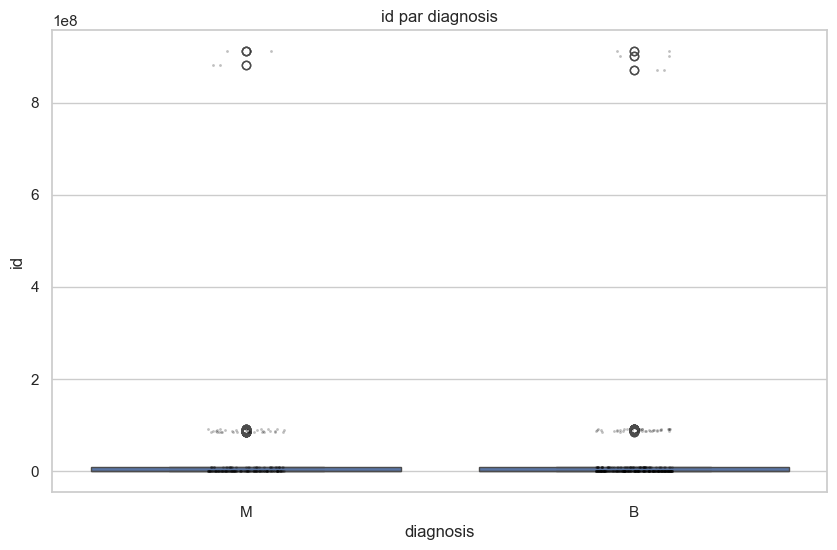

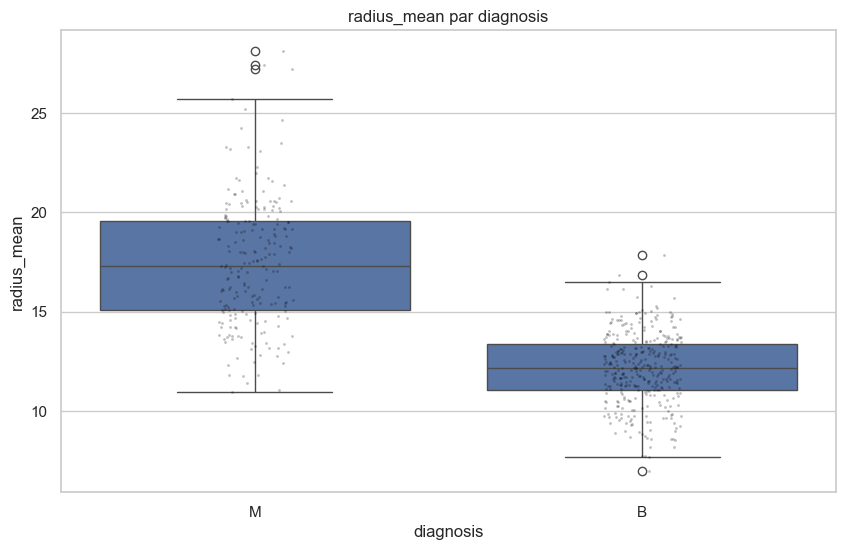

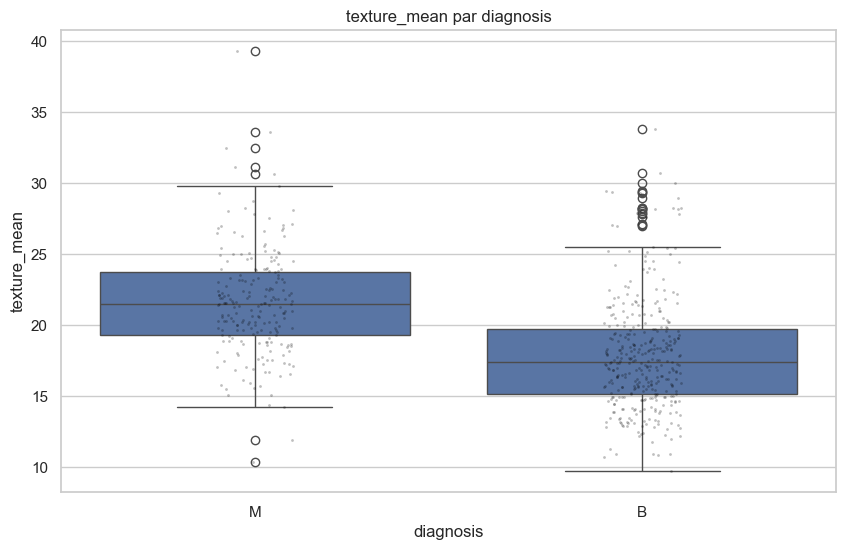

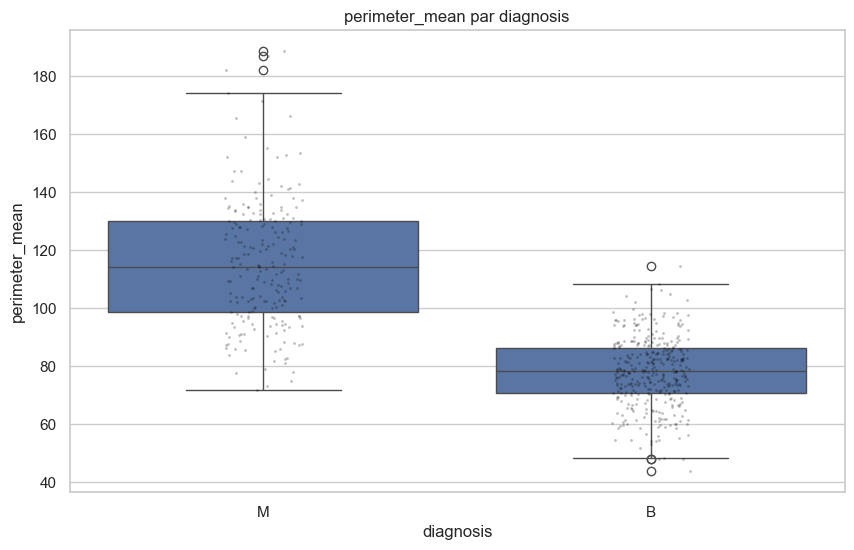

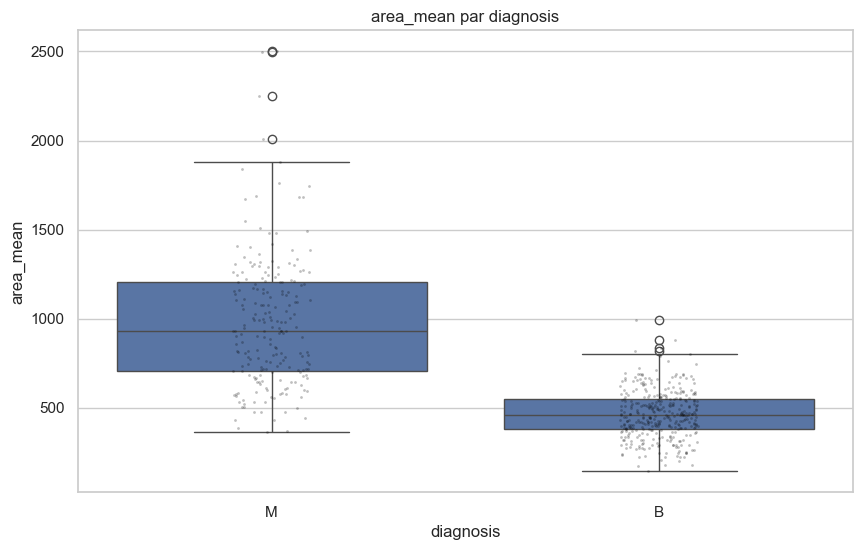

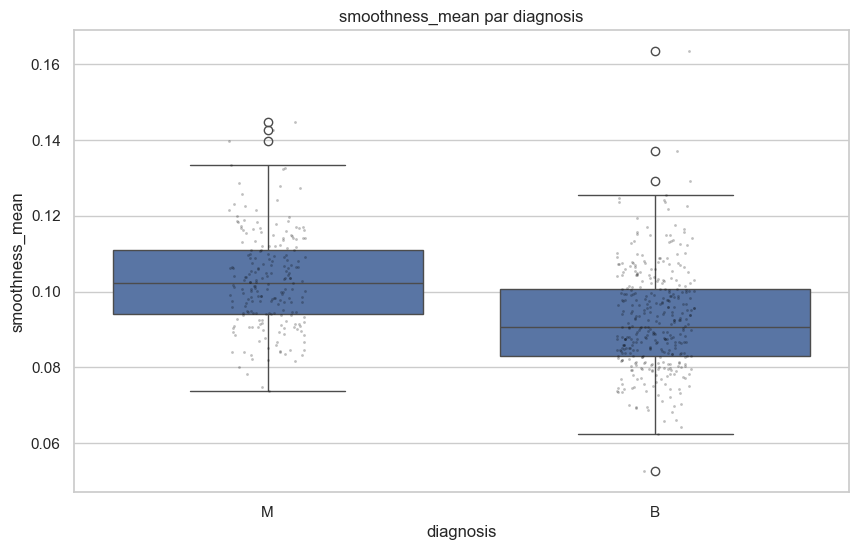

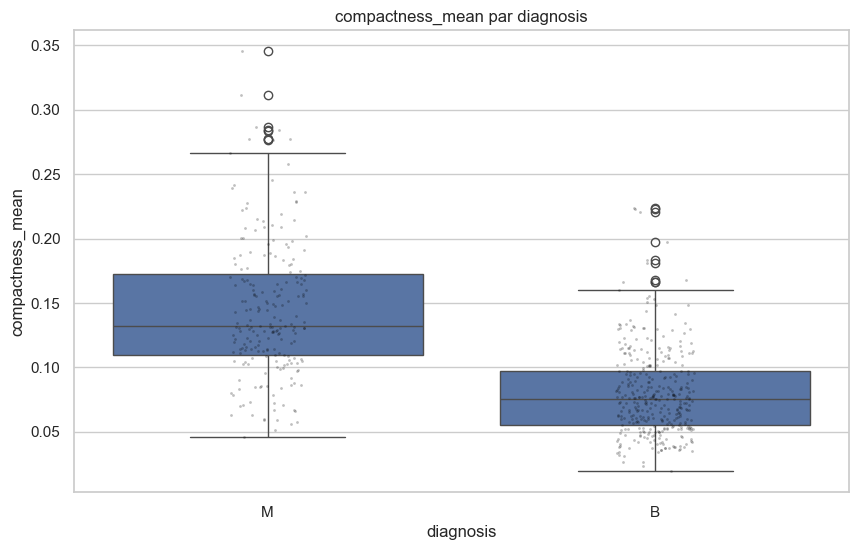

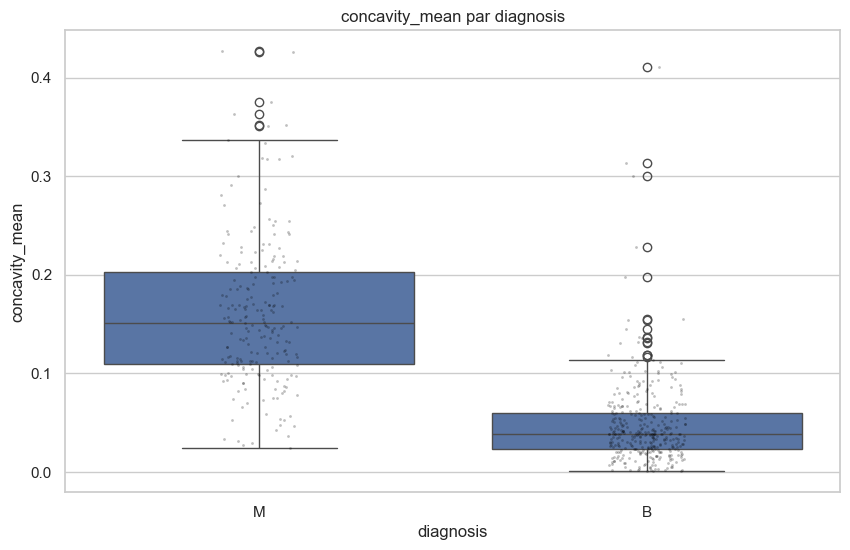

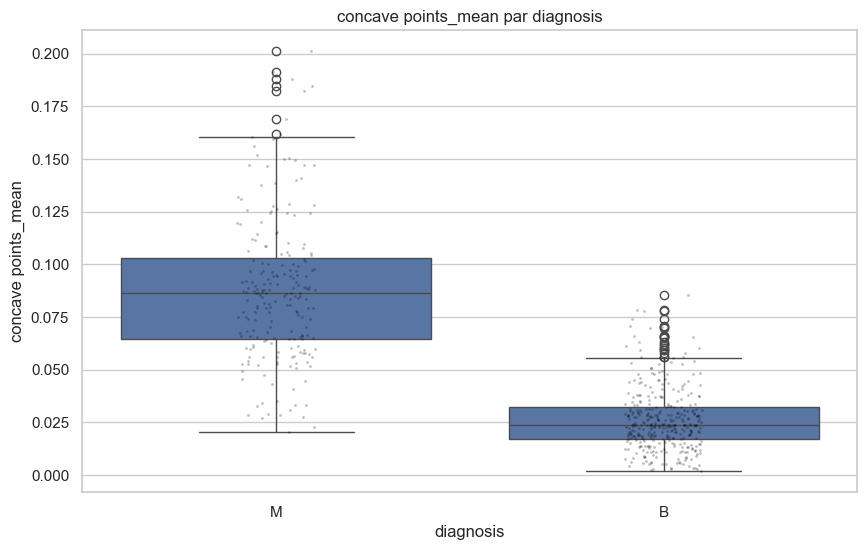

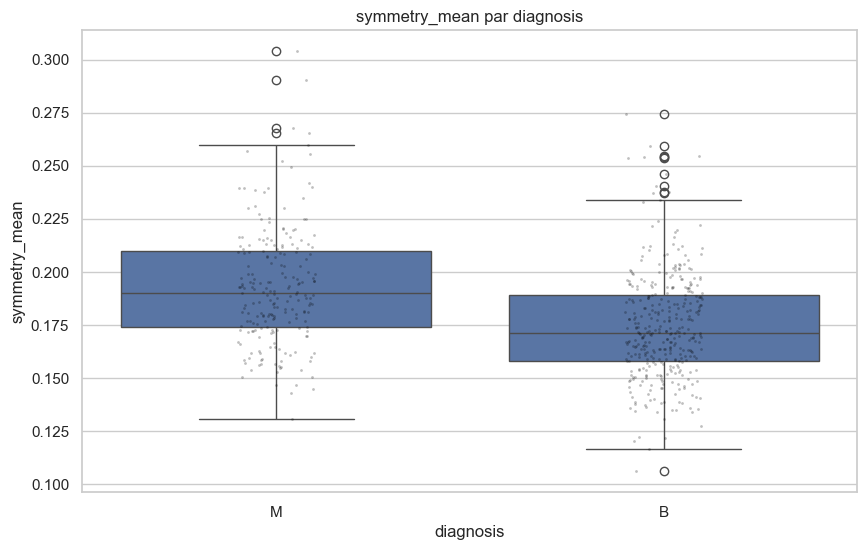

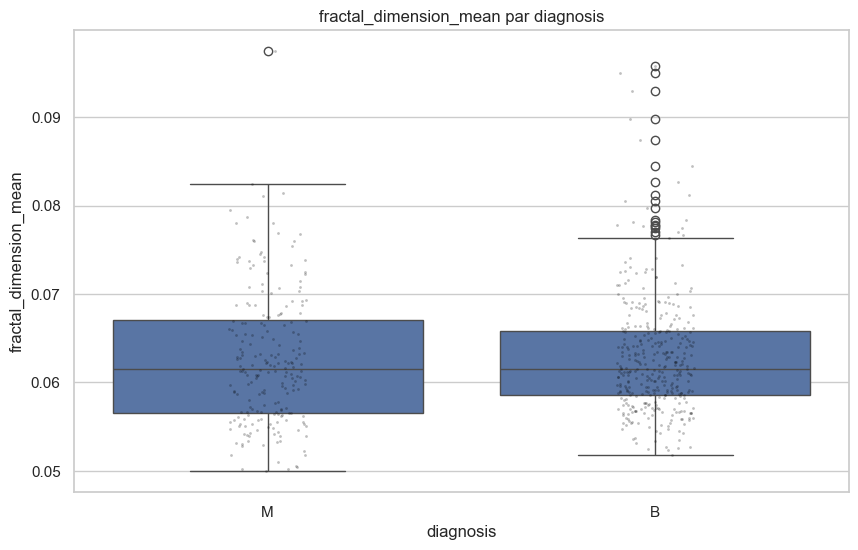

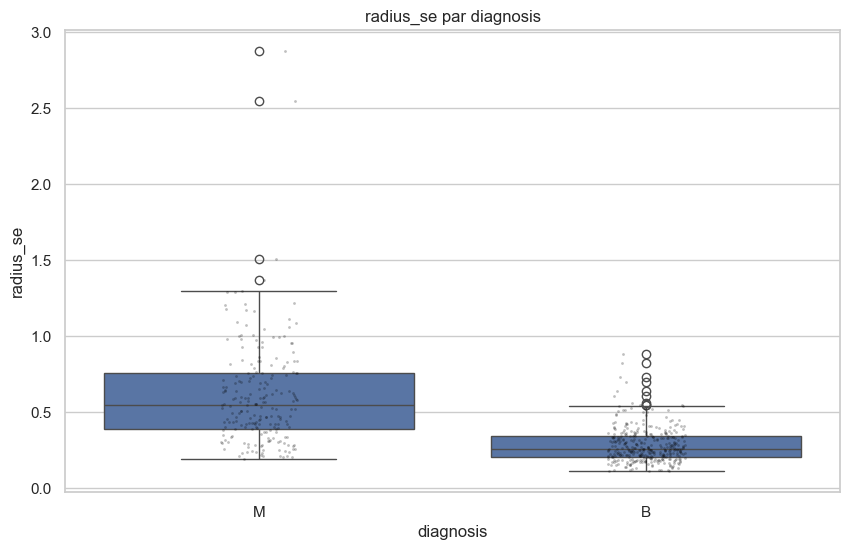

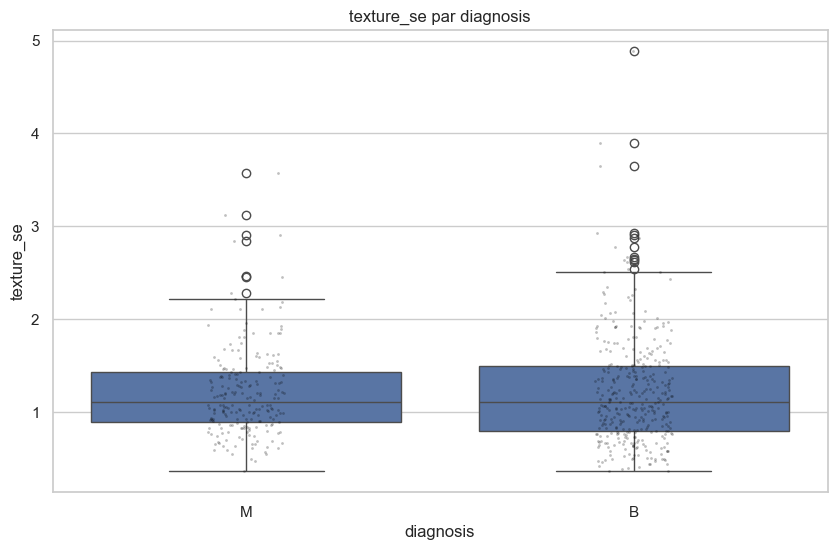

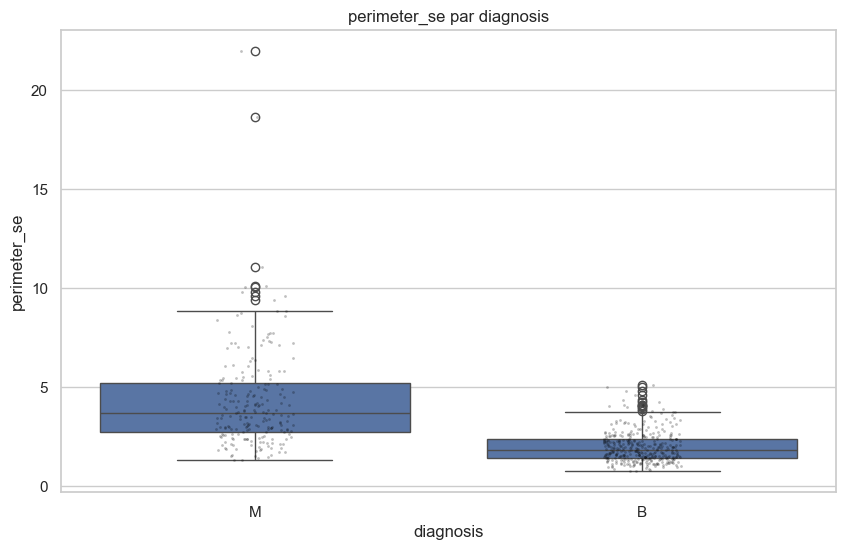

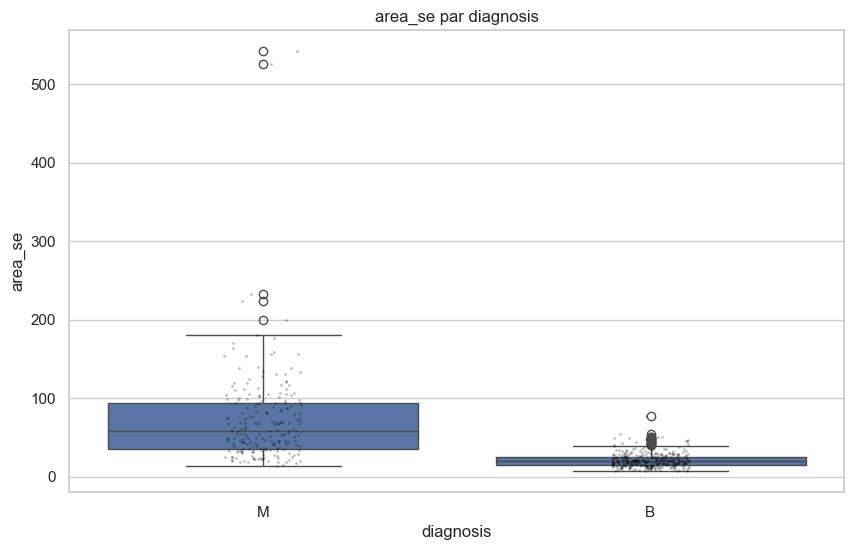

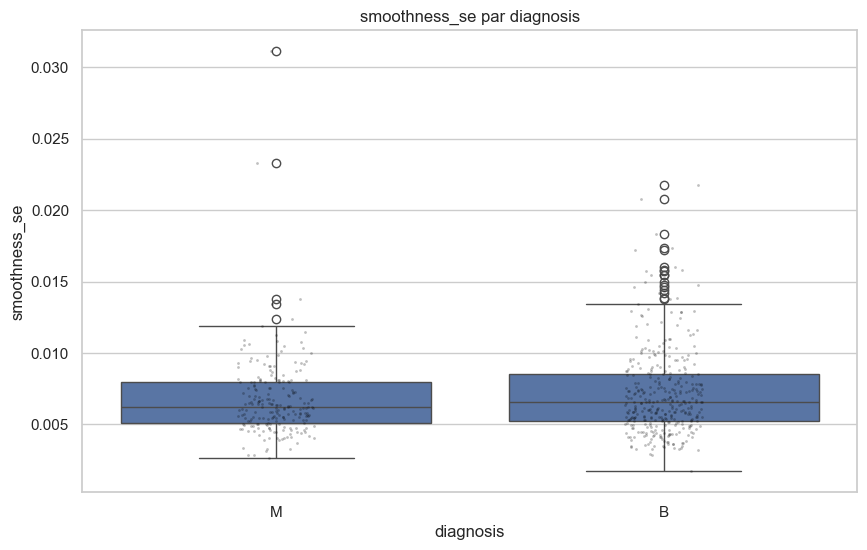

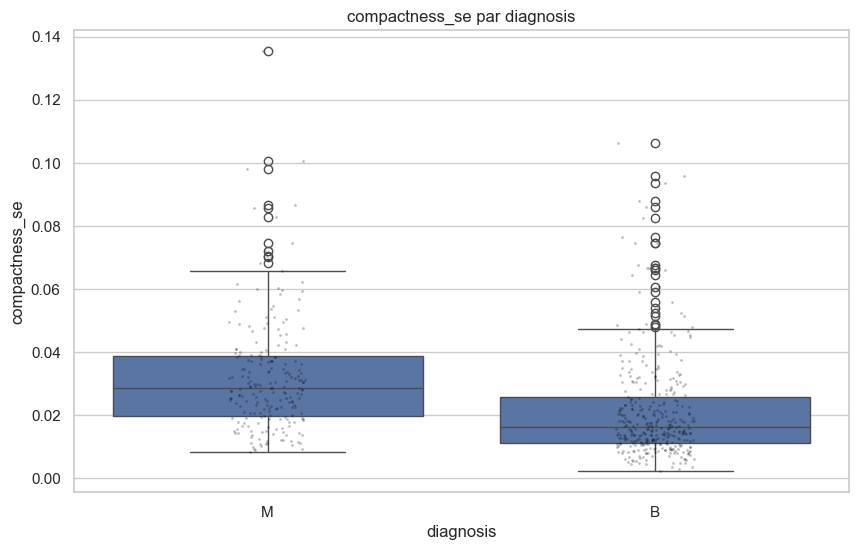

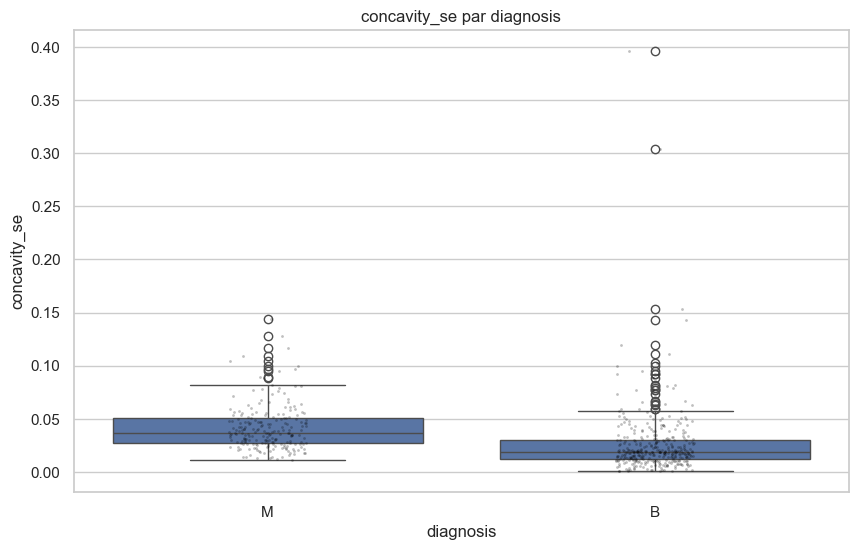

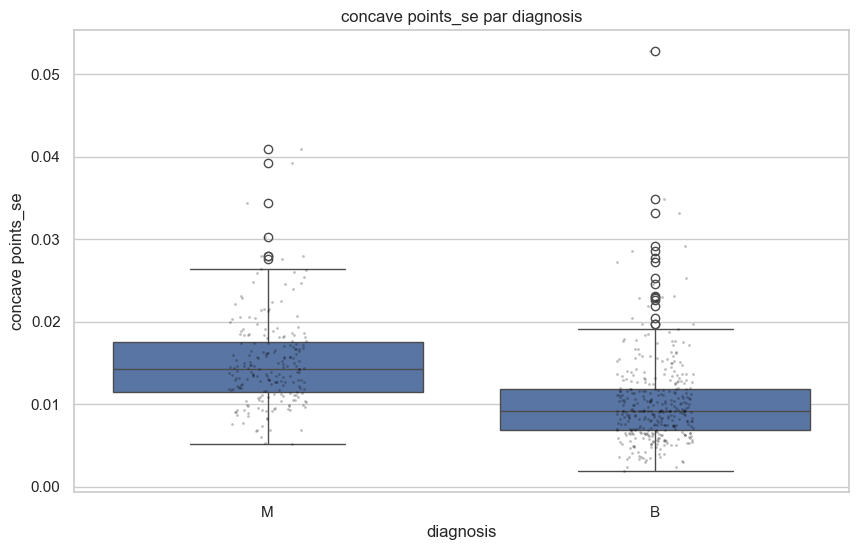

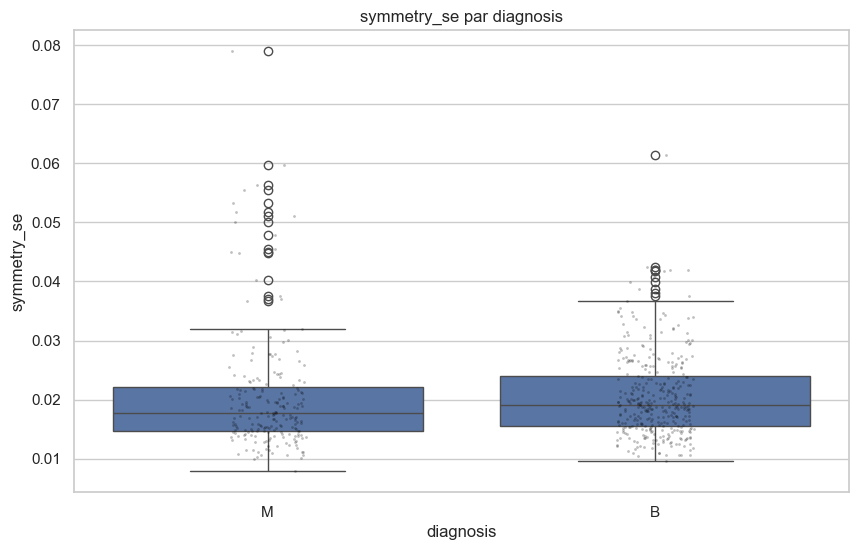

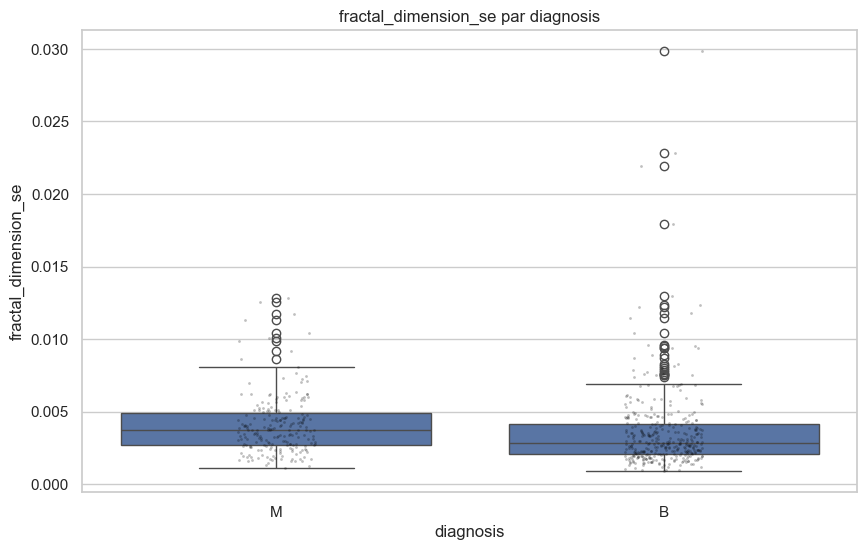

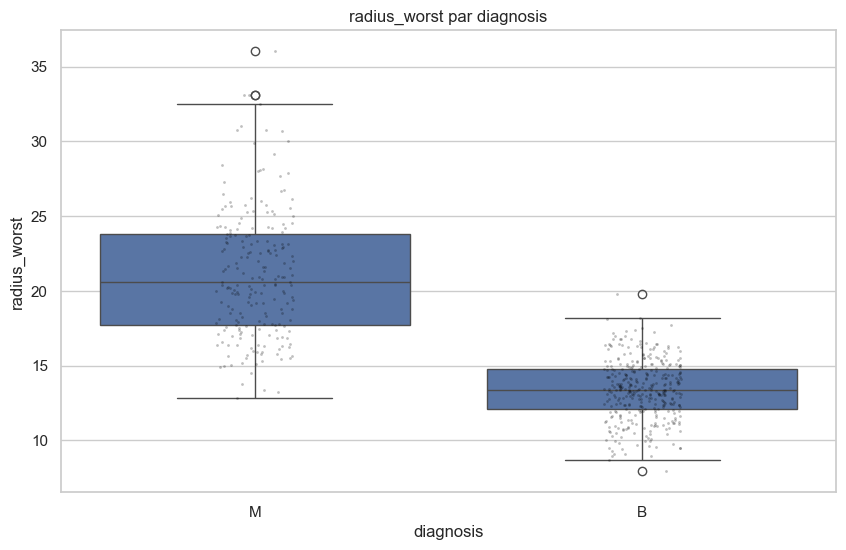

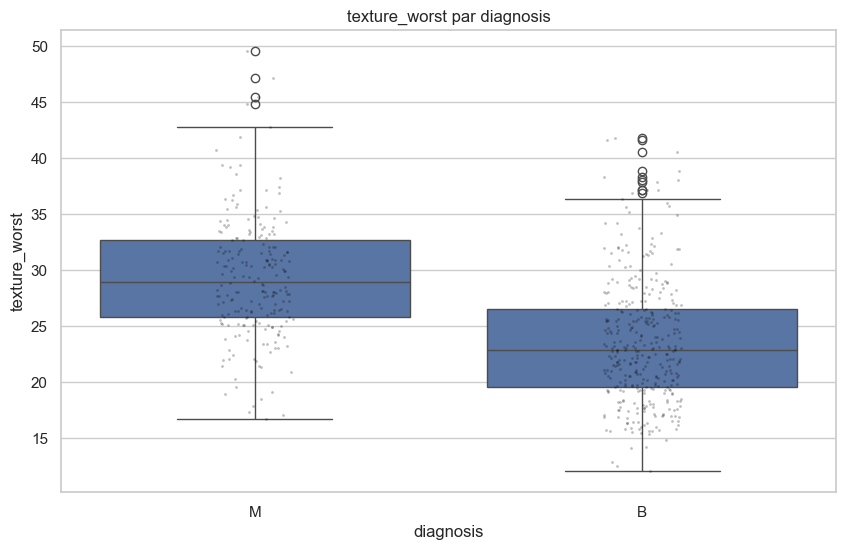

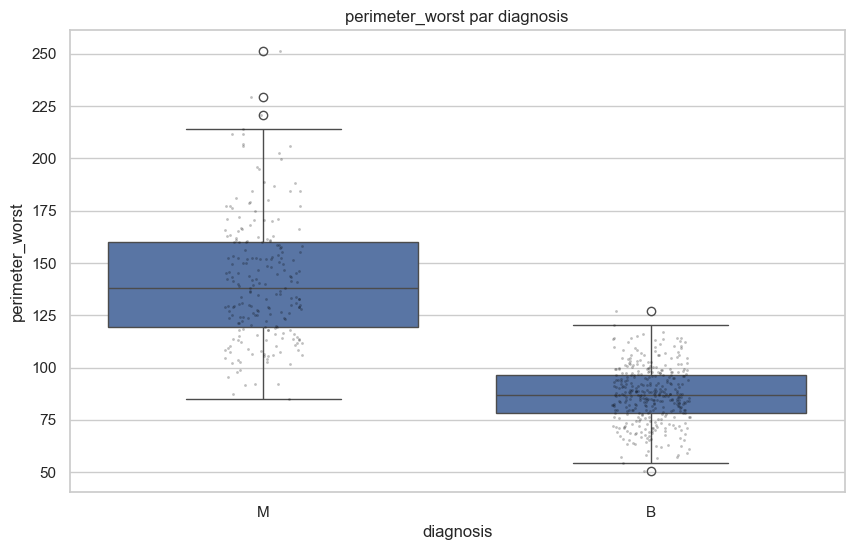

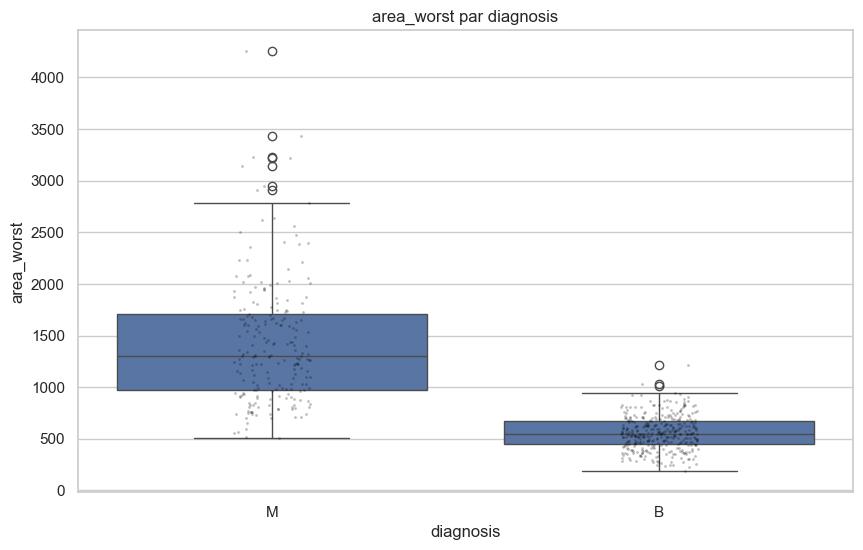

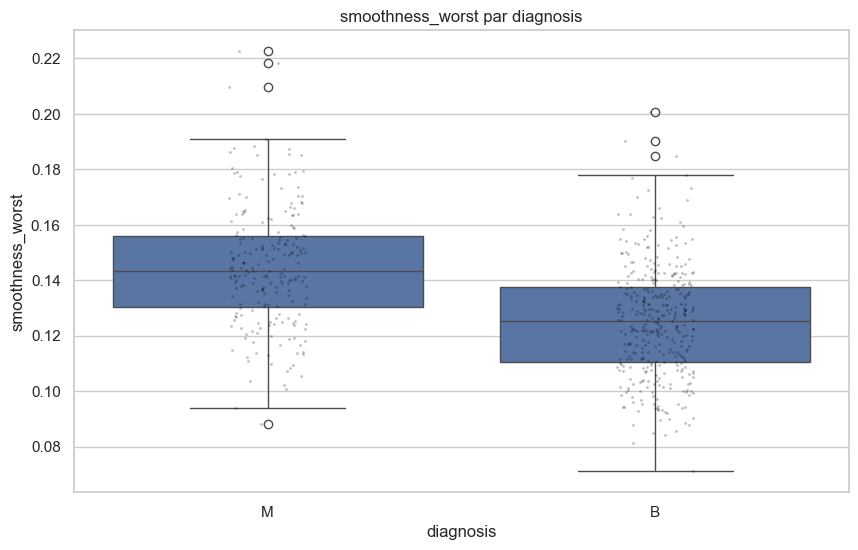

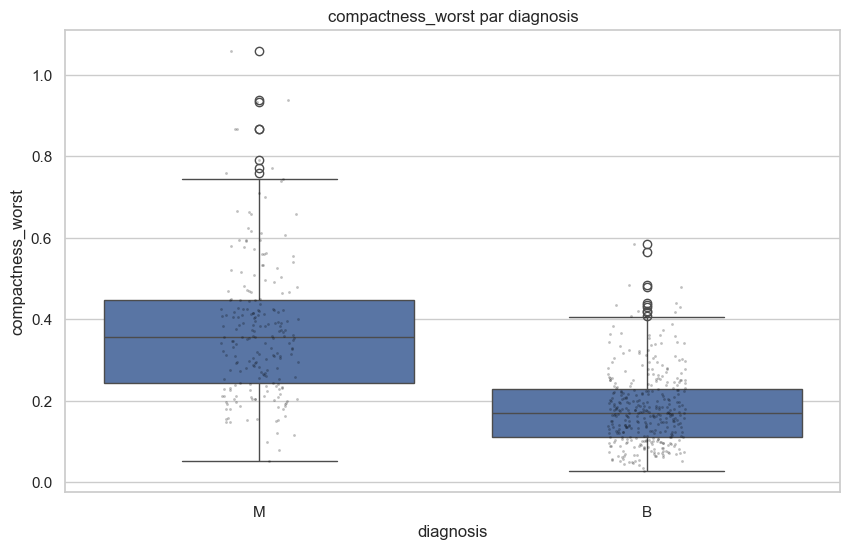

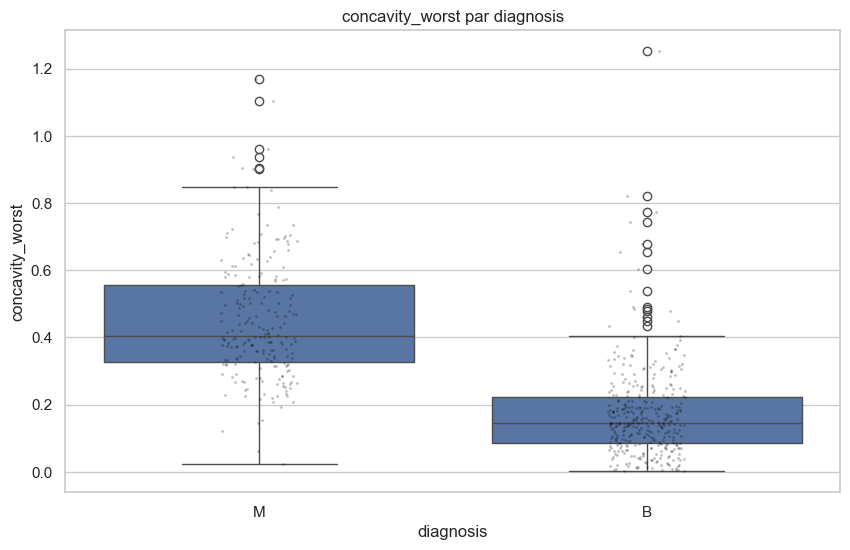

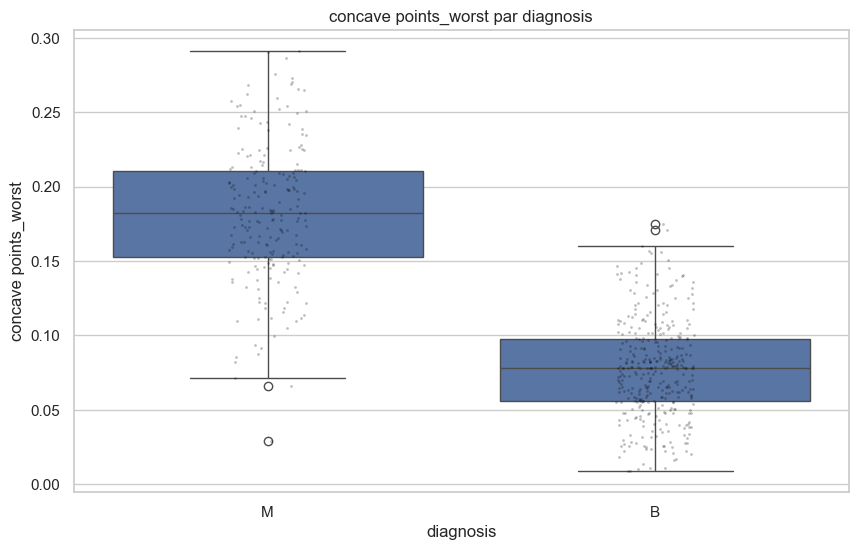

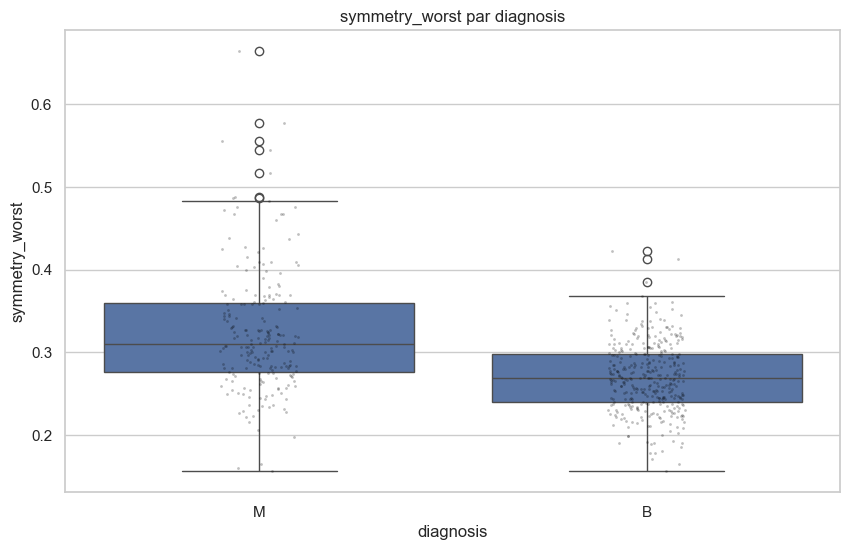

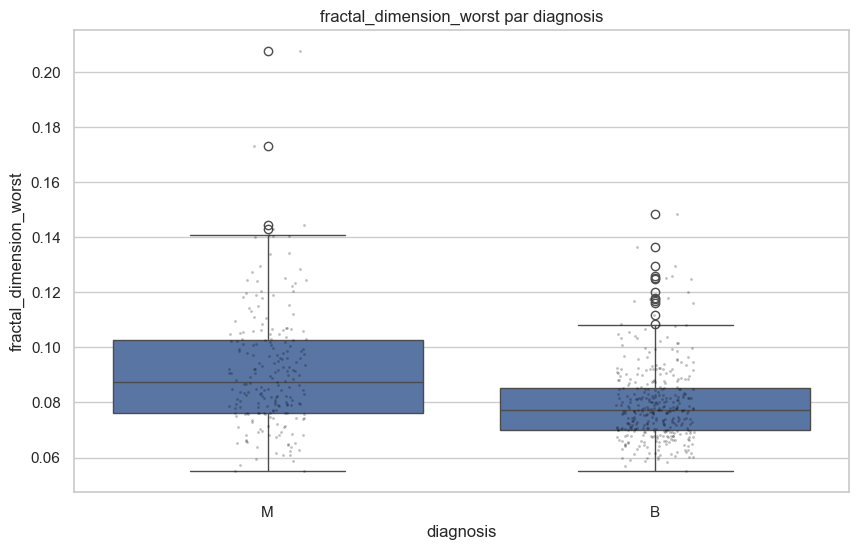

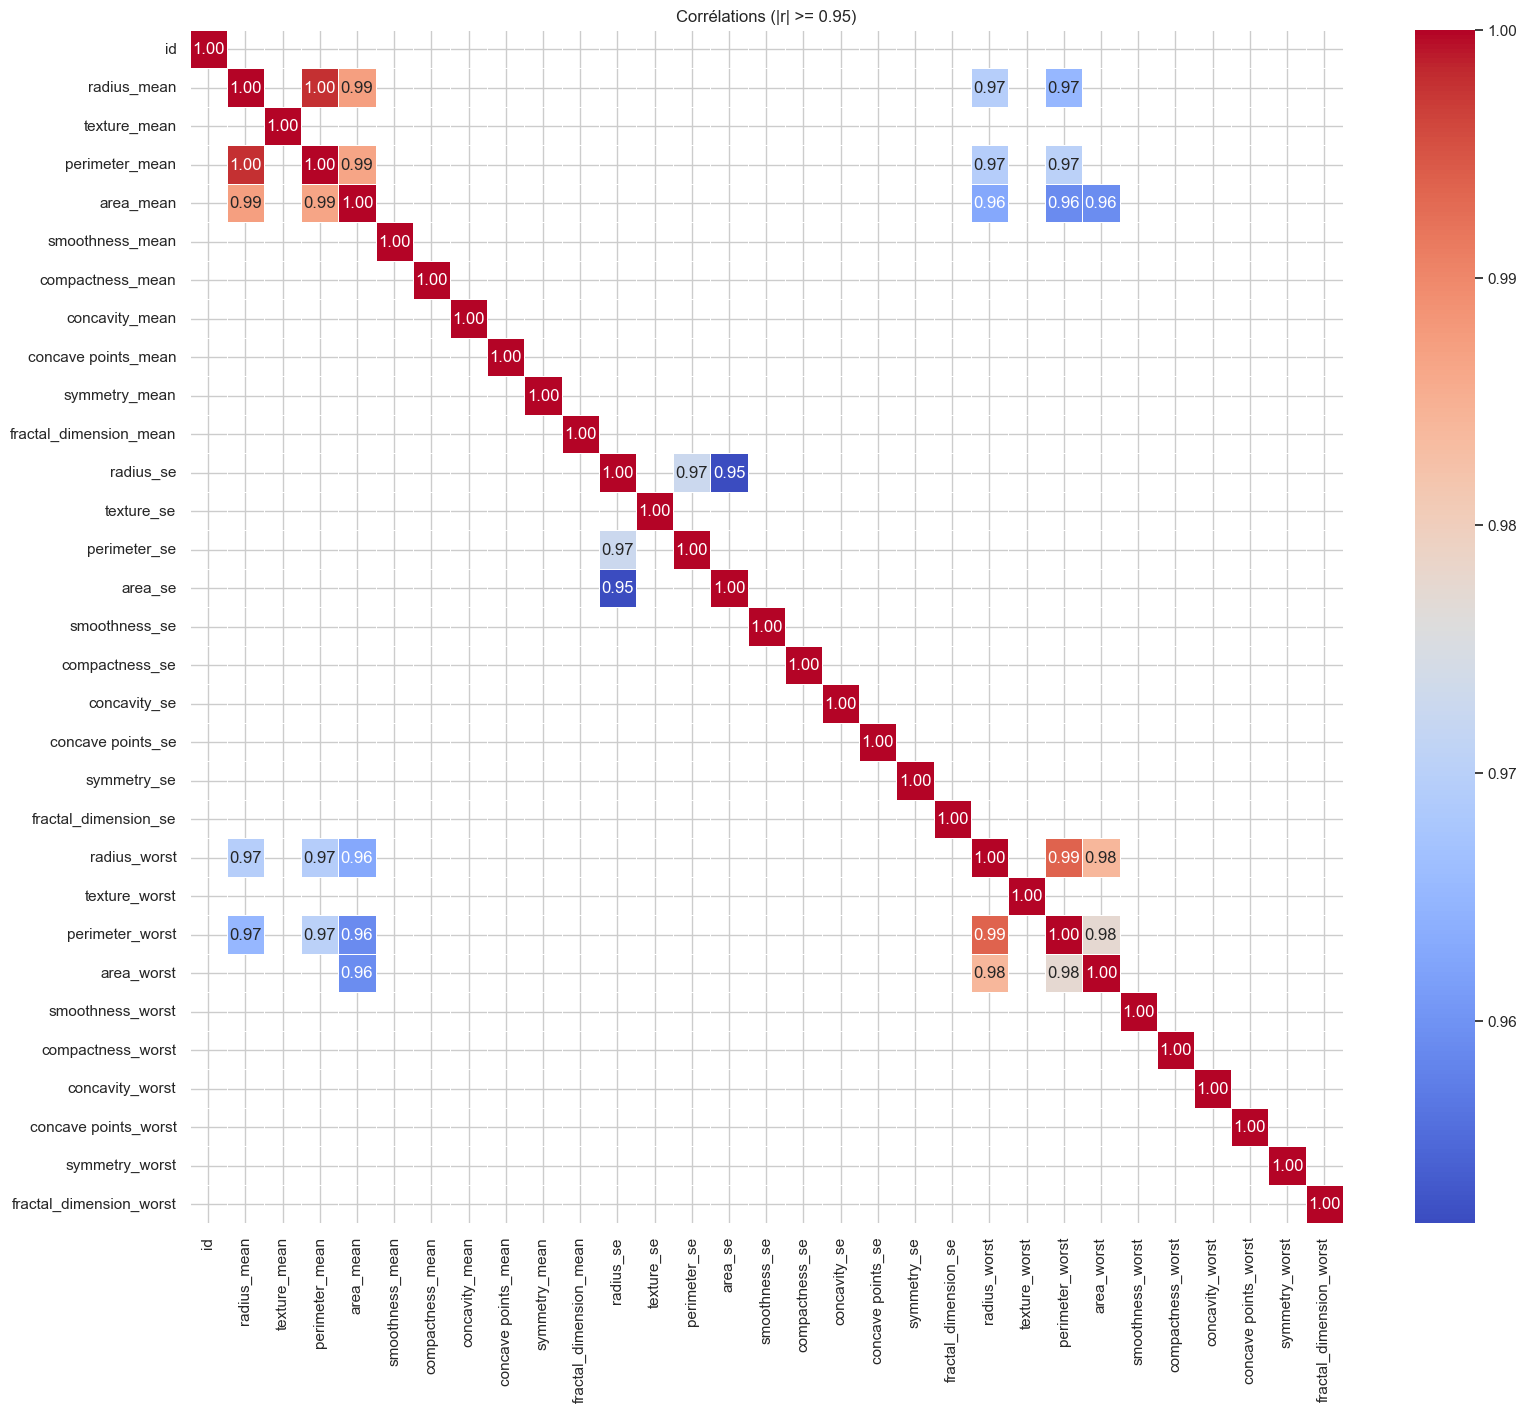

In [28]:
# Visualisations
sns.set(style="whitegrid")

# Boxplots par cible pour chaque colonne numérique
if targetColumn is None or targetColumn not in df.columns:
    print("Définissez targetColumn pour les boxplots comparatifs.")
else:
    for col in numCols:
        plt.figure(figsize=figSize)
        sns.boxplot(data=df, x=targetColumn, y=col)
        sns.stripplot(data=df, x=targetColumn, y=col, color='black', alpha=0.25, size=2)
        plt.title(f"{col} par {targetColumn}")
        plt.show()

# Heatmap des corrélations numériques (seuil ajustable)
if len(numCols) >= 2:
    corr = df[numCols].corr(method='pearson')
    # Masquer les faibles corrélations en valeur absolue
    maskLow = corr.abs() < heatmapCorrThreshold
    corrMasked = corr.mask(maskLow)
    plt.figure(figsize=(max(8, len(numCols)*0.6), max(6, len(numCols)*0.5)))
    sns.heatmap(corrMasked, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5, linecolor='white', square=False)
    plt.title(f"Corrélations (|r| >= {heatmapCorrThreshold})")
    plt.show()
else:
    print("Corrélation: nécessite au moins 2 colonnes numériques.")


Reduction de la dimensionnalité :
- Cluster de corrélation
- Evaluation par Boruta

D'après la matrice de corrèlation : 
- radius_mean, permeter_mean, area_mean, radius_worst, permiter_worst et area_worst sont correlées : On conserve uniquement radius_worst
- radius_se, permiter_se, area_se sont correlées : On conserve uniquement radius_se

In [29]:
# Évaluation Perceptron sous forme de fonction
from typing import Sequence, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"

# Liste de colonnes à exclure (modifiez directement ici pour vos tests)
excludedColumns = [
    "radius_mean",
    "perimeter_mean",
    "area_mean",
    "perimeter_se",
    "area_se",
    "perimeter_worst",
    "area_worst",
    "id"
]

def evaluatePerceptron(excludeColumns: Optional[Sequence[str]] = None) -> dict:
    if targetColumn is None or targetColumn not in df.columns:
        raise ValueError("Définissez targetColumn pour l'entraînement.")

    X = df.drop(columns=[targetColumn, "id"], errors="ignore")
    y = df[targetColumn]

    # Conserve uniquement les colonnes numériques
    Xnum = X.select_dtypes(include=[np.number]).copy()

    # Applique les exclusions si fournies
    usedExclude = []
    if excludeColumns:
        usedExclude = [c for c in excludeColumns if c in Xnum.columns]
        if len(usedExclude) > 0:
            Xnum = Xnum.drop(columns=usedExclude)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        Xnum, y, test_size=0.2, random_state=randomSeed, stratify=y
    )

    # Standardisation
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modèle
    clf = Perceptron(random_state=randomSeed)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)

    # Métriques robustes (classe positive = minoritaire si binaire)
    acc = accuracy_score(y_test, y_pred)
    vcTrain = pd.Series(y_train).value_counts()
    if len(vcTrain.index) == 2:
        positiveClass = vcTrain.index[-1]
        prec = precision_score(y_test, y_pred, pos_label=positiveClass, zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label=positiveClass, zero_division=0)
    else:
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

    print("Colonnes exclues:" if usedExclude else "Aucune exclusion appliquée.")
    for c in usedExclude:
        print(f" - {c}")
    print(f"Accuracy: {acc:.3f} | Précision: {prec:.3f} | Rappel: {rec:.3f}")

    return {
        "excluded": usedExclude,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "features": list(Xnum.columns),
    }

# Exemples d'appels
print("-- Baseline (toutes colonnes numériques) --")
_ = evaluatePerceptron()
print("\n-- Avec excludedColumns --")
_ = evaluatePerceptron(excludedColumns)


-- Baseline (toutes colonnes numériques) --
Aucune exclusion appliquée.
Accuracy: 0.939 | Précision: 0.973 | Rappel: 0.857

-- Avec excludedColumns --
Colonnes exclues:
 - radius_mean
 - perimeter_mean
 - area_mean
 - perimeter_se
 - area_se
 - perimeter_worst
 - area_worst
Accuracy: 0.974 | Précision: 0.976 | Rappel: 0.952


Gain d'accuacy et de rappel ce qui signifie moins de faux negatif donc on peut valider ces choix.

In [30]:
# Sélection de variables rapide avec BorutaPy
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"
if targetColumn is None or targetColumn not in df.columns:
    raise ValueError("Définissez targetColumn pour Boruta.")

# Réutilise la même liste d'exclusions que la cellule Perceptron, si présente
try:
    excludedColumns
except NameError:
    excludedColumns = []

# Prépare X (numérique uniquement) et y
colsToDrop = [targetColumn] + (["id"] if "id" in df.columns else []) + [c for c in excludedColumns if c in df.columns]
X = df.drop(columns=colsToDrop, errors="ignore")
Xnum = X.select_dtypes(include=[np.number]).copy()
if Xnum.shape[1] == 0:
    raise ValueError("Aucune colonne numérique disponible pour Boruta.")

# Remplir les NaN restants par la médiane de colonne
for c in Xnum.columns:
    if Xnum[c].isna().any():
        Xnum[c] = Xnum[c].fillna(Xnum[c].median())

# Encode y si non numérique
ySeries = df[targetColumn]
if not pd.api.types.is_numeric_dtype(ySeries):
    yEncoded = ySeries.astype("category").cat.codes.values
else:
    yEncoded = ySeries.values

# Modèle de base pour Boruta
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=randomSeed,
    n_jobs=-1,
    class_weight="balanced"
)
boruta = BorutaPy(estimator=rf, n_estimators='auto', random_state=randomSeed, verbose=0)

# Entraînement Boruta
boruta.fit(Xnum.values, yEncoded)

selected = list(Xnum.columns[boruta.support_])
weak = list(Xnum.columns[boruta.support_weak_])
rejected = [c for c in Xnum.columns if c not in selected and c not in weak]

print("-- Résultat Boruta --")
print(f"Sélectionnées (fortes): {len(selected)}")
print(f"Sélectionnées (faibles): {len(weak)}")
print(f"Rejetées: {len(rejected)}")

if selected:
    print("Colonnes conservées (fortes):")
    print(", ".join(selected))
if weak:
    print("Colonnes faiblement soutenues (à évaluer):")
    print(", ".join(weak))
if rejected:
    print("Colonnes à retirer potentiellement (rejetées):")
    print(", ".join(rejected))


-- Résultat Boruta --
Sélectionnées (fortes): 21
Sélectionnées (faibles): 1
Rejetées: 1
Colonnes conservées (fortes):
texture_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, fractal_dimension_mean, radius_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst
Colonnes faiblement soutenues (à évaluer):
symmetry_mean
Colonnes à retirer potentiellement (rejetées):
texture_se


In [31]:
excludedColumnsBoruta = [
    "radius_mean",
    "perimeter_mean",
    "area_mean",
    "perimeter_se",
    "area_se",
    "perimeter_worst",
    "area_worst",
    "id",
    "texture_se"
]

excludedColumnsBoruta2 = [
    "radius_mean",
    "perimeter_mean",
    "area_mean",
    "perimeter_se",
    "area_se",
    "perimeter_worst",
    "area_worst",
    "id",
    "texture_se",
    "symmetry_mean"
]

print("-- Baseline (toutes colonnes numériques) --")
_ = evaluatePerceptron()
print("\n-- Avec excludedColumns --")
_ = evaluatePerceptron(excludedColumns)
print("\n-- Avec excludedColumnsBoruta (Colonnes à retirer) --")
_ = evaluatePerceptron(excludedColumnsBoruta)
print("\n-- Avec excludedColumnsBoruta2 (Colonnes faiblement soutenues) --")
_ = evaluatePerceptron(excludedColumnsBoruta2)

-- Baseline (toutes colonnes numériques) --
Aucune exclusion appliquée.
Accuracy: 0.939 | Précision: 0.973 | Rappel: 0.857

-- Avec excludedColumns --
Colonnes exclues:
 - radius_mean
 - perimeter_mean
 - area_mean
 - perimeter_se
 - area_se
 - perimeter_worst
 - area_worst
Accuracy: 0.974 | Précision: 0.976 | Rappel: 0.952

-- Avec excludedColumnsBoruta (Colonnes à retirer) --
Colonnes exclues:
 - radius_mean
 - perimeter_mean
 - area_mean
 - perimeter_se
 - area_se
 - perimeter_worst
 - area_worst
 - texture_se
Accuracy: 0.974 | Précision: 0.953 | Rappel: 0.976

-- Avec excludedColumnsBoruta2 (Colonnes faiblement soutenues) --
Colonnes exclues:
 - radius_mean
 - perimeter_mean
 - area_mean
 - perimeter_se
 - area_se
 - perimeter_worst
 - area_worst
 - texture_se
 - symmetry_mean
Accuracy: 0.974 | Précision: 0.953 | Rappel: 0.976


Les exclusions proposé par Boruta maintienne l'accuracy et augmente le rappel au detriment de la précision (aucun changement en ignorant la variable faiblement soutenue), comme on privilégie les faux positifs sur les faux negatifs le rappel est la stat à privilégié.
On peut donc exclure les variabes proposé par Boruta.

On à un accuracy de 0.974 et un rappel à 0.976, ce qu est très satisfaisant, il ne semble pas necessaire de tenter de reduire plus que ça les variables.

Composantes nécessaires pour 95% de variance: 9/21


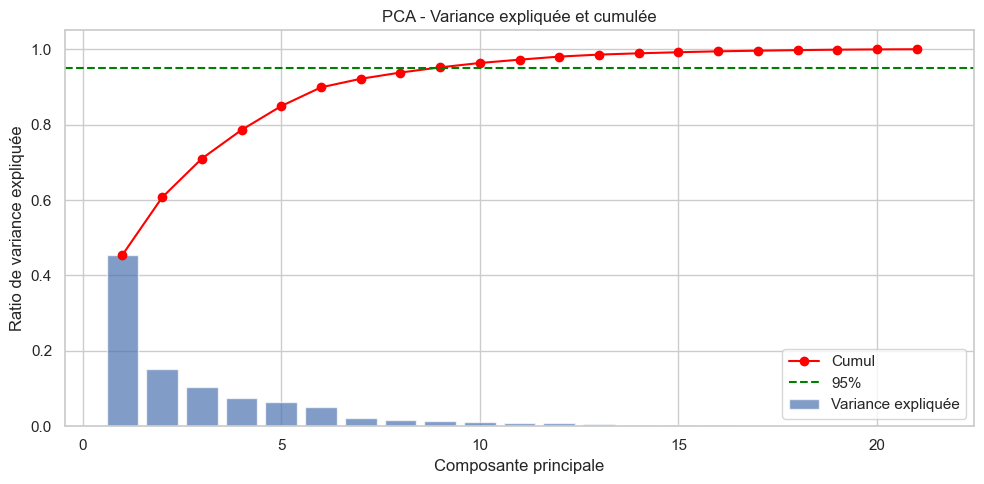

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"
assert isinstance(targetColumn, str) and targetColumn in df.columns, "targetColumn doit être défini et présent dans df"

# Colonnes à exclure (cible, id, exclusions Boruta si définies)
dropCols = [targetColumn]
if "id" in df.columns:
    dropCols.append("id")
try:
    dropCols += [c for c in excludedColumnsBoruta2 if c in df.columns]
except NameError:
    pass

# Numériques uniquement
Xdf = df.drop(columns=dropCols, errors="ignore").select_dtypes(include=[np.number])
if Xdf.shape[1] == 0:
    raise ValueError("Aucune colonne numérique disponible pour PCA.")

Xarray = Xdf.apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)

# Standardisation
scaler = StandardScaler()
Xstd = scaler.fit_transform(Xarray)

# PCA
pca = PCA(n_components=None, svd_solver="auto")
Xpca = pca.fit_transform(Xstd)
explainedVariance = pca.explained_variance_ratio_
explainedVarianceCumulative = np.cumsum(explainedVariance)

k95 = int(np.searchsorted(explainedVarianceCumulative, 0.95) + 1)
print(f"Composantes nécessaires pour 95% de variance: {k95}/{Xdf.shape[1]}")

plt.figure(figsize=(10, 5))
idx = np.arange(1, explainedVariance.shape[0] + 1)
plt.bar(idx, explainedVariance, alpha=0.7, label="Variance expliquée")
plt.plot(idx, explainedVarianceCumulative, color="red", marker="o", label="Cumul")
plt.axhline(0.95, color="green", linestyle="--", label="95%")
plt.xlabel("Composante principale")
plt.ylabel("Ratio de variance expliquée")
plt.title("PCA - Variance expliquée et cumulée")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Test du perceptron (implémentation maison) avec affichage des métriques
from script import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import numpy as np
import random as rd

# Colonnes à exclure si définies ailleurs
try:
    excludedColumns
except NameError:
    excludedColumns = []

# Prépare X/y (numériques uniquement) et conversion stricte
dropCols = [targetColumn]
if "id" in df.columns:
    dropCols.append("id")
dropCols += [c for c in excludedColumnsBoruta2 if c in df.columns]

Xdf = df.drop(columns=dropCols, errors="ignore").select_dtypes(include=[np.number])
X_array = Xdf.apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)

y_series = df[targetColumn]
if not pd.api.types.is_numeric_dtype(y_series):
    y_array = y_series.astype("category").cat.codes.to_numpy()
else:
    y_array = pd.to_numeric(y_series, errors="coerce").fillna(0).astype(int).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_array, y_array, test_size=0.3, random_state=rd.randint(0,40000), stratify=y_array
)

# Standardisation
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# PCA à 9 composantes (95% de variance atteinte)
pca = PCA(n_components=9, svd_solver="auto")
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

nb_iter_list = list(range(1, 101))
learning_rate_list = [0.1, 0.01, 0.001, 0.0001]

results = []

for lr in learning_rate_list:
    for n_iter in nb_iter_list:
        model = Perceptron(X_train_pca.shape[1], lr, n_iter)
        model.fitBatch(X_train_pca, y_train)
        
        # Prédictions train et test
        y_pred_train = model.predict(X_train_pca)
        y_pred_test = model.predict(X_test_pca)
        
        # Métriques
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)
        test_prec = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
        test_rec = recall_score(y_test, y_pred_test, average="macro", zero_division=0)
        
        results.append({
            'lr': lr,
            'n_iter': n_iter,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_prec': test_prec,
            'test_rec': test_rec,
            'gap': train_acc - test_acc  
        })

results_df = pd.DataFrame(results)

# Meilleure configuration
best_idx = results_df['test_acc'].idxmax()
best_config = results_df.iloc[best_idx]

print(f"\nMEILLEURE CONFIGURATION:")
print(f"   Learning rate: {best_config['lr']}")
print(f"   Itérations: {best_config['n_iter']}")
print(f"   Test accuracy: {best_config['test_acc']:.4f}")
print(f"   Test precision: {best_config['test_prec']:.4f}")
print(f"   Test recall: {best_config['test_rec']:.4f}")
print(f"   Train accuracy: {best_config['train_acc']:.4f}")
print(f"   Gap (train-test): {best_config['gap']:.4f}")


MEILLEURE CONFIGURATION:
   Learning rate: 0.1
   Itérations: 61.0
   Test accuracy: 0.9825
   Test precision: 0.9828
   Test recall: 0.9797
   Train accuracy: 0.9799
   Gap (train-test): -0.0026


In [39]:
# Validation croisée stratifiée (k=20) pour Perceptron
from script import Perceptron
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import numpy as np
import random as rd

# Sécuriser variables externes si absentes
try:
    excludedColumns
except NameError:
    excludedColumns = []

try:
    excludedColumnsBoruta2
except NameError:
    excludedColumnsBoruta2 = []

# Prépare X/y (numériques uniquement) et conversion stricte
dropCols = [targetColumn]
if "id" in df.columns:
    dropCols.append("id")
dropCols += [c for c in excludedColumnsBoruta2 if c in df.columns]

Xdf = df.drop(columns=dropCols, errors="ignore").select_dtypes(include=[np.number])
X_array = Xdf.apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)

y_series = df[targetColumn]
if not pd.api.types.is_numeric_dtype(y_series):
    y_array = y_series.astype("category").cat.codes.to_numpy()
else:
    y_array = pd.to_numeric(y_series, errors="coerce").fillna(0).astype(int).to_numpy()

# Grilles d'hyperparamètres
nbIterList = list(range(1, 101))
learningRateList = [0.1, 0.01, 0.001, 0.0001]

# CV stratifiée 20 plis
skf = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

results = []

for lr in learningRateList:
    for nIter in nbIterList:
        foldAccs = []
        foldPrecs = []
        foldRecs = []
        foldTrainAccs = []

        for trainIdx, valIdx in skf.split(X_array, y_array):
            X_train, X_val = X_array[trainIdx], X_array[valIdx]
            y_train, y_val = y_array[trainIdx], y_array[valIdx]

            # Standardisation par pli
            scaler = StandardScaler()
            X_train_std = scaler.fit_transform(X_train)
            X_val_std = scaler.transform(X_val)

            # PCA à 9 composantes (95% de variance atteinte)
            pca = PCA(n_components=9, svd_solver="auto")
            X_train_pca = pca.fit_transform(X_train_std)
            X_val_pca = pca.transform(X_val_std)

            model = Perceptron(X_train_pca.shape[1], lr, nIter)
            model.fitBatch(X_train_pca, y_train)

            y_pred_train = model.predict(X_train_pca)
            y_pred_val = model.predict(X_val_pca)

            trainAcc = accuracy_score(y_train, y_pred_train)
            valAcc = accuracy_score(y_val, y_pred_val)
            valPrec = precision_score(y_val, y_pred_val, average="macro", zero_division=0)
            valRec = recall_score(y_val, y_pred_val, average="macro", zero_division=0)

            foldTrainAccs.append(trainAcc)
            foldAccs.append(valAcc)
            foldPrecs.append(valPrec)
            foldRecs.append(valRec)

        results.append({
            "lr": lr,
            "nIter": nIter,
            "meanAcc": float(np.mean(foldAccs)),
            "stdAcc": float(np.std(foldAccs, ddof=1)),
            "meanPrec": float(np.mean(foldPrecs)),
            "meanRec": float(np.mean(foldRecs)),
            "meanTrainAcc": float(np.mean(foldTrainAccs)),
            "gap": float(np.mean(foldTrainAccs) - np.mean(foldAccs))
        })

results_df = pd.DataFrame(results).sort_values(by="meanAcc", ascending=False).reset_index(drop=True)

# Meilleure configuration
bestConfig = results_df.iloc[0]

print(f"\nMEILLEURE CONFIGURATION (CV 20 plis):")
print(f"   Learning rate: {bestConfig['lr']}")
print(f"   Itérations: {bestConfig['nIter']}")
print(f"   Accuracy moyenne: {bestConfig['meanAcc']:.4f} ± {bestConfig['stdAcc']:.4f}")
print(f"   Précision moyenne: {bestConfig['meanPrec']:.4f}")
print(f"   Rappel moyen: {bestConfig['meanRec']:.4f}")
print(f"   Train accuracy moyenne: {bestConfig['meanTrainAcc']:.4f}")
print(f"   Gap (train - val): {bestConfig['gap']:.4f}")

results_df.head(10)


MEILLEURE CONFIGURATION (CV 20 plis):
   Learning rate: 0.0001
   Itérations: 68.0
   Accuracy moyenne: 0.9737 ± 0.0250
   Précision moyenne: 0.9755
   Rappel moyen: 0.9709
   Train accuracy moyenne: 0.9788
   Gap (train - val): 0.0051


,lr,nIter,meanAcc,stdAcc,meanPrec,meanRec,meanTrainAcc,gap
0,0.0001,68,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9788171767,0.0051102801
1,0.0100,87,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9802983159,0.0065914193
2,0.0010,68,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9788171767,0.0051102801
3,0.0010,87,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9802983159,0.0065914193
4,0.1000,68,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9788171767,0.0051102801
5,0.0001,87,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9802983159,0.0065914193
6,0.1000,87,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9802983159,0.0065914193
7,0.0100,68,0.9737068966,0.0250491872,0.9754691653,0.9709031491,0.9788171767,0.0051102801
8,0.0010,97,0.9736453202,0.0276199838,0.9739183331,0.9726708259,0.9802057233,0.0065604031
9,0.0001,97,0.9736453202,0.0276199838,0.9739183331,0.9726708259,0.9802057233,0.0065604031


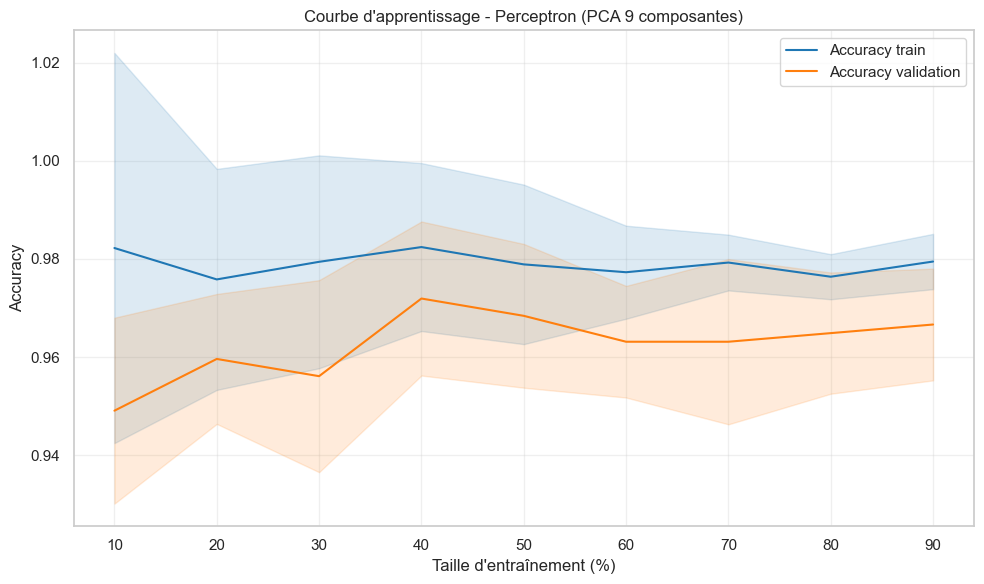

In [ ]:
# Courbe d'apprentissage avec PCA (9 composantes) et Perceptron (implémentation maison)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from script import Perceptron

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"
assert isinstance(targetColumn, str) and targetColumn in df.columns, "targetColumn doit être défini et présent dans df"

colsToDrop = [targetColumn]
if "id" in df.columns:
    colsToDrop.append("id")
try:
    colsToDrop += [c for c in excludedColumnsBoruta2 if c in df.columns]
except NameError:
    pass

Xdf = df.drop(columns=colsToDrop, errors="ignore").select_dtypes(include=[np.number])
X_array = Xdf.apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)

y_series = df[targetColumn]
if not pd.api.types.is_numeric_dtype(y_series):
    y_array = y_series.astype("category").cat.codes.to_numpy()
else:
    y_array = pd.to_numeric(y_series, errors="coerce").fillna(0).astype(int).to_numpy()

# Hyperparamètres du Perceptron: on réutilise la meilleure config si disponible, sinon défaut
try:
    lrBest = float(best_config['lr'])
    nIterBest = int(best_config['n_iter'])
except Exception:
    lrBest = 0.1
    nIterBest = 50

# Tailles relatives d'entraînement pour la courbe d'apprentissage
trainSizeFractions = np.linspace(0.1, 1.0, 10)

kFolds = 5
skf = StratifiedKFold(n_splits=kFolds, shuffle=True, random_state=42)

meanTrainAcc = []
stdTrainAcc = []
meanValAcc = []
stdValAcc = []

for frac in trainSizeFractions:
    foldTrainAcc = []
    foldValAcc = []

    for trainIdx, valIdx in skf.split(X_array, y_array):
        X_train_full, y_train_full = X_array[trainIdx], y_array[trainIdx]
        X_val, y_val = X_array[valIdx], y_array[valIdx]

        # Sous-échantillonnage stratifié du jeu d'entraînement à la fraction demandée
        try:
            sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=42)
            subTrainIdx, _ = next(sss.split(X_train_full, y_train_full))
        except ValueError:
            # Si la fraction est trop petite pour maintenir la stratification sur ce pli
            continue

        X_train, y_train = X_train_full[subTrainIdx], y_train_full[subTrainIdx]

        # Standardisation + PCA (fit sur train uniquement)
        scaler = StandardScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_val_std = scaler.transform(X_val)

        pca = PCA(n_components=9, svd_solver="auto")
        X_train_pca = pca.fit_transform(X_train_std)
        X_val_pca = pca.transform(X_val_std)

        # Perceptron custom
        model = Perceptron(X_train_pca.shape[1], lrBest, nIterBest)
        model.fitBatch(X_train_pca, y_train)

        y_pred_train = model.predict(X_train_pca)
        y_pred_val = model.predict(X_val_pca)

        foldTrainAcc.append(accuracy_score(y_train, y_pred_train))
        foldValAcc.append(accuracy_score(y_val, y_pred_val))

    # Agrégation des métriques (ignorer les tailles impossibles)
    if len(foldTrainAcc) == 0:
        meanTrainAcc.append(np.nan)
        stdTrainAcc.append(np.nan)
        meanValAcc.append(np.nan)
        stdValAcc.append(np.nan)
    else:
        meanTrainAcc.append(float(np.mean(foldTrainAcc)))
        stdTrainAcc.append(float(np.std(foldTrainAcc, ddof=1)))
        meanValAcc.append(float(np.mean(foldValAcc)))
        stdValAcc.append(float(np.std(foldValAcc, ddof=1)))

# Tracé
xPercent = trainSizeFractions * 100.0
plt.figure(figsize=(10, 6))
plt.plot(xPercent, meanTrainAcc, label="Accuracy train", color="#1f77b4")
plt.fill_between(xPercent,
                 np.array(meanTrainAcc) - np.array(stdTrainAcc),
                 np.array(meanTrainAcc) + np.array(stdTrainAcc),
                 color="#1f77b4", alpha=0.15)

plt.plot(xPercent, meanValAcc, label="Accuracy validation", color="#ff7f0e")
plt.fill_between(xPercent,
                 np.array(meanValAcc) - np.array(stdValAcc),
                 np.array(meanValAcc) + np.array(stdValAcc),
                 color="#ff7f0e", alpha=0.15)

plt.xlabel("Taille d'entraînement (%)")
plt.ylabel("Accuracy")
plt.title("Courbe d'apprentissage - Perceptron (PCA 9 composantes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Courbe d'apprentissage: nombre d'erreurs par epoch (PCA 9)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from script import Perceptron

assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"

# Prépare X/y comme précédemment (exclusions Boruta2)
dropCols = [targetColumn]
if "id" in df.columns:
    dropCols.append("id")
try:
    dropCols += [c for c in excludedColumnsBoruta2 if c in df.columns]
except NameError:
    pass

Xdf = df.drop(columns=dropCols, errors="ignore").select_dtypes(include=[np.number])
X_array = Xdf.apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)

y_series = df[targetColumn]
if not pd.api.types.is_numeric_dtype(y_series):
    y_array = y_series.astype("category").cat.codes.to_numpy()
else:
    y_array = pd.to_numeric(y_series, errors="coerce").fillna(0).astype(int).to_numpy()

# Split train/val pour tracer les erreurs par epoch (courbe unique)
X_train, X_val, y_train, y_val = train_test_split(
    X_array, y_array, test_size=0.3, random_state=42, stratify=y_array
)

# Standardisation + PCA
theScaler = StandardScaler()
X_train_std = theScaler.fit_transform(X_train)
X_val_std = theScaler.transform(X_val)

pca = PCA(n_components=9, svd_solver="auto")
X_train_pca = pca.fit_transform(X_train_std)
X_val_pca = pca.transform(X_val_std)

# Hyperparamètres choisis (reprend meilleurs si dispo)
try:
    lrBest = float(best_config['lr'])
    nIterBest = int(best_config['n_iter'])
except Exception:
    lrBest = 0.1
    nIterBest = 50

# Entrainement avec historique d'erreurs
model = Perceptron(X_train_pca.shape[1], lrBest, nIterBest)
history = model.fitBatchHistory(X_train_pca, y_train, XVal=X_val_pca, YVal=y_val)

trainErrors = history["trainErrors"]
valErrors = history["valErrors"] if history["valErrors"] is not None else None

# Tracé
epochs = np.arange(1, len(trainErrors) + 1)
plt.figure(figsize=(10,6))
plt.plot(epochs, trainErrors, label="Erreurs train/epoch", color="#1f77b4")
if valErrors is not None:
    plt.plot(epochs, valErrors, label="Erreurs val/epoch", color="#ff7f0e")
plt.xlabel("Epoch")
plt.ylabel("Nombre d'erreurs")
plt.title("Courbe d'apprentissage - Erreurs par epoch (PCA 9)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
